# TUTORIAL-I: Introduction to Bfrescox
**Ozge Surer (Northwestern), Filomena Nunes (Michigan State), Matt Plumlee (Northwestern), Stefan Wild (Argonne)**

## Interfacing `frescox` with `surmise`

In this section, we illustrate how to interface ``frescox`` with ``surmise``, a Python package
for uncertainty quantification. More information about ``surmise`` can be found at <https://surmise.readthedocs.io/en/latest/>.

We demonstrate how ``frescox`` and ``surmise`` work together with two different
examples (please see scripts ``example_surmise1.py`` and ``example_surmise2.py``). In the first example, we fit an emulator to calibrate our computer model.
In the second example, we directly use computer model outputs without fitting an emulator to be used in the calibration.

In [1]:
%%bash
cd /content
git clone --branch v0.2.0 https://github.com/bandframework/bandframework.git
git clone https://github.com/LLNL/Frescox.git
mkdir Frescoxex
cp bandframework/software/Bfrescox/makefiles/googlecolab/makefile Frescox/source/
cd Frescox/source
make
make install
make clean

gfortran -Wall -w  -cpp -c -O2  globx7.f
gfortran -Wall -w  -cpp -c -O2  version_number.f
gfortran -Wall -w  -cpp -O1 -c frxx1.f
gfortran -Wall -w  -cpp -c -O2  frxx2.f
gfortran -Wall -w  -cpp -c -O2  frxx3.f
gfortran -Wall -w  -cpp -c -O2  frxx3b.f
gfortran -Wall -w  -cpp -c -O2  f14arm64.f
gfortran -Wall -w  -cpp -c -O2  frxx0.f
gfortran -Wall -w  -cpp -c -O2  frxx4.f
gfortran -Wall -w  -cpp -c -O2  frxx7a.f
gfortran -Wall -w  -cpp -c -O2  frxx5.f
gfortran -Wall -w  -cpp -c -O2  frxx6.f
gfortran -Wall -w  -cpp -c -O2  erwinrc4.f
gfortran -Wall -w  -cpp -c -O2  frxx7b.f
gfortran -Wall -w  -cpp -c -O2  frxx8.f
gfortran -Wall -w  -cpp -c -O2  frxx9.f
gfortran -Wall -w  -cpp -c -O2  frxx10.f
gfortran -Wall -w  -cpp -c -O2  frxx11.f
gfortran -Wall -w  -cpp -c -O2  bincc.f
gfortran -Wall -w  -cpp -c -O2  frxx13.f
gfortran -Wall -w  -cpp -c -O2  frxx16.f
gfortran -Wall -w  -cpp -c -O2  frxx17.f
gfortran -Wall -w  -cpp -c -O2  frxx21.f
gfortran -Wall -w  -cpp -c -O2  lagmesh.f
gfortran -Wall

Cloning into 'bandframework'...
Note: switching to '0a97b9d2b868567ae28bf1deae7c7b9358ec61d2'.

You are in 'detached HEAD' state. You can look around, make experimental
changes and commit them, and you can discard any commits you make in this
state without impacting any branches by switching back to a branch.

If you want to create a new branch to retain commits you create, you may
do so (now or later) by using -c with the switch command. Example:

  git switch -c <new-branch-name>

Or undo this operation with:

  git switch -

Turn off this advice by setting config variable advice.detachedHead to false

Cloning into 'Frescox'...


In [2]:
%%bash
cd /content
pip install surmise
pip install smt
pip install matplotlib==3.10 seaborn==0.13.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 864.2/864.2 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 29.4 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 964.8/964.8 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.6/66.6 kB 5.8 MB/s eta 0:00:00


In [3]:
import os
import subprocess
import scipy.stats as sps
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
from surmise.emulation import emulator
from surmise.calibration import calibrator
from smt.sampling_methods import LHS
import pandas as pd
import seaborn as sns
import pylab

## Define some functions to run frescox

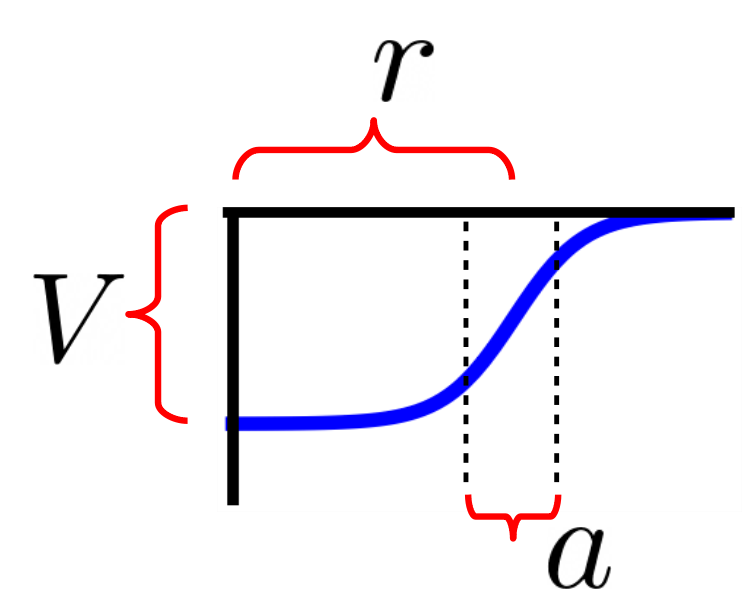

In [4]:
from IPython.display import Image
Image("/content/bandframework/software/Bfrescox/Tutorial_I/parameters.png")

In [5]:
def generate_input_file(parameter_values):
    os.chdir("/content/bandframework/software/Bfrescox/Tutorial_I/python_scripts")
    file = 'frescox_inputs/48Ca_template.in'

    with open(file) as f:
        content = f.readlines()

    no_p = 0;
    for idx, line in enumerate(content):
        if 'XXXXX' in line:
            no_param = line.count('XXXXX')
            line_temp = line
            for i in range(no_param):
                line_temp = line_temp.replace("XXXXX", str(parameter_values[no_p]), 1)
                no_p += 1

            content[idx] = line_temp

    f = open("frescox_inputs/frescox_temp_input.in", "a")
    f.writelines(content)
    f.close()

In [6]:
def frescox_output(input_file='frescox_inputs/frescox_temp_input.in',
                   output_file='frescox_outputs/48Ca_temp.out'):

    commands = '''
      export PATH=$PATH:/content/Frescoxex
      cd /content/bandframework/software/Bfrescox/Tutorial_I/python_scripts
      mkdir frescox_outputs
      frescox < frescox_inputs/frescox_temp_input.in > frescox_outputs/48Ca_temp.out
    '''

    # Execute frescox
    bashresults = subprocess.run(commands, capture_output=True, shell=True)

    # Read outputs
    os.chdir("/content/bandframework/software/Bfrescox/Tutorial_I/python_scripts")

    with open(output_file) as f:
        content = f.readlines()

    sigma_omega_ratio = []
    for idline, line in enumerate(content):
        if ('X-S' in line):
            sigma_omega_ratio.append(float(line.split()[4]))

    os.remove(input_file)
    os.remove(output_file)

    return sigma_omega_ratio

In [7]:
def frescox_run(theta):
    theta_list = theta.tolist()
    f_l = []
    for para_obs in theta_list:
        para_obs += [3.5,1,0.3]
        generate_input_file(para_obs)
        exp_output = frescox_output()
        f_l.append(exp_output)

    return np.asarray(f_l).T

## Generate training and test data

In [8]:
# Define x (input) and f (function evaluation)
lower = np.array([40, 0.7, 0.5])
upper = np.array([60, 1.2, 0.8])
### ### ### ### ### ###  ### ### ### EXERCISE ### ### ###  ### ### ### ### ### ###
### batch_size = 50, batch_size = 100, batch_size = 200, batch_size = 300 ###
### ### ### ### ### ###  ### ### ### EXERCISE ### ### ###  ### ### ### ### ### ###
batch_size = 300
thetalimits = np.concatenate((lower[:, None], upper[:, None]), axis=1)
sampling = LHS(xlimits=thetalimits)
theta_tr = sampling(batch_size)

f_tr_1 = frescox_run(theta_tr)
x_tr = np.array(range(181)).reshape((181, 1))

In [9]:
# (Test) draw 50 random parameters from the prior
sampling = LHS(xlimits=thetalimits)
theta_test = sampling(50)
f_test_1 = frescox_run(theta_test)
x_test = np.array(range(181)).reshape((181, 1))

f_test = f_test_1
f_tr = f_tr_1

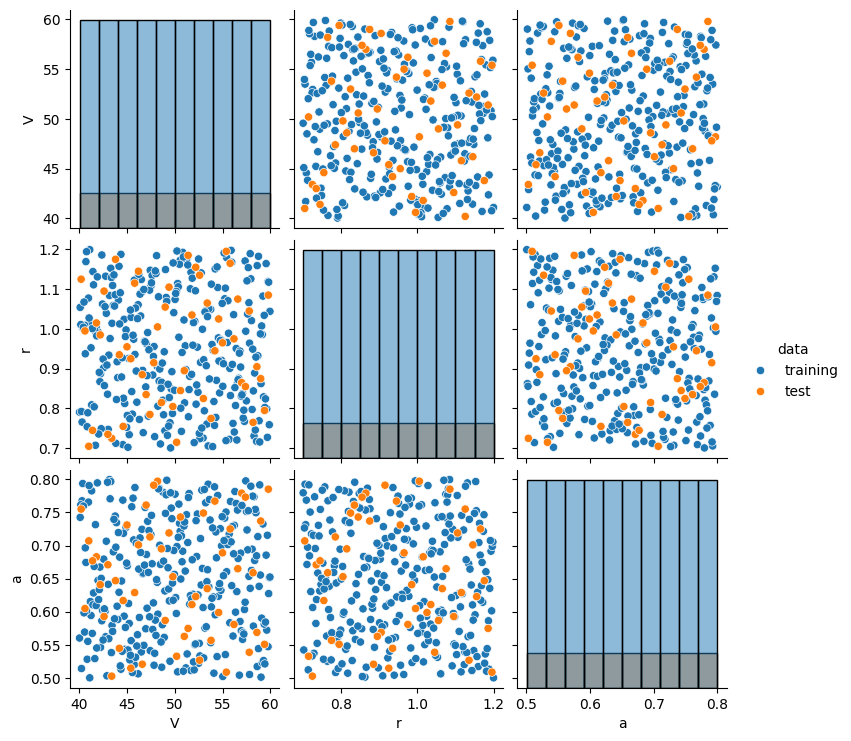

In [10]:
# Observe parameters
df = pd.DataFrame(theta_tr, columns = ['V','r','a'])
df_test = pd.DataFrame(theta_test, columns = ['V','r','a'])
df['data'] = 'training'
df_test['data'] = 'test'
frames = [df, df_test]
frames = pd.concat(frames)
sns.pairplot(frames, hue='data', diag_kind="hist")

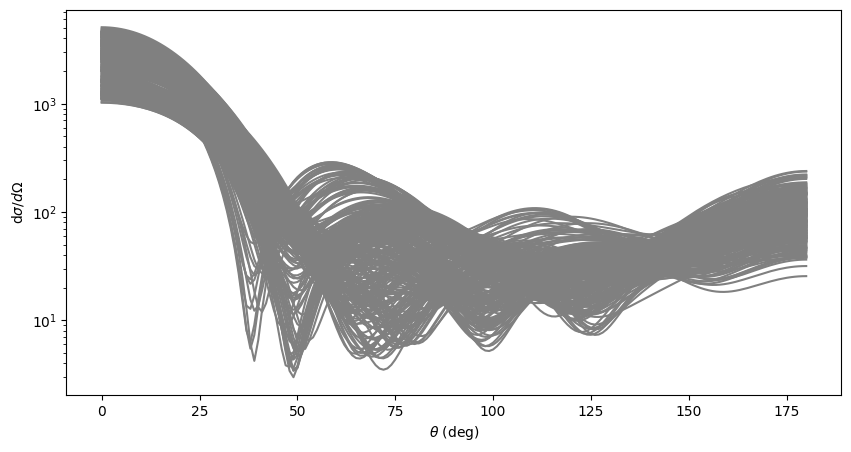

In [11]:
# Observe simulation outcomes
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 1, 1)
for i in range(f_tr.shape[1]):
  ax.plot(x_tr, f_tr[:, i], color='grey', zorder=1)
plt.xlabel(r'$\theta$ (deg)')
plt.ylabel(r'd$\sigma/d\Omega$')
ax.set_yscale('log')
pylab.show()

## Build an emulator via `surmise`

In [12]:
# Build an emulator for the frescox simulation
emu_fresco = emulator(x=x_tr,
                      theta=theta_tr,
                      f=f_tr,
                      method='PCGPwM',
                      args={'epsilon': 0.1,
                             'hypregmean': -8})

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [13]:
# Get the prediction means and variances

pred_emu = emu_fresco.predict(x=x_test, theta=theta_test)

pred_m, pred_var = pred_emu.mean(), pred_emu.var()

pred_emu_tr = emu_fresco.predict(x=x_tr, theta=theta_tr)

pred_m_tr, pred_var_tr = pred_emu_tr.mean(), pred_emu_tr.var()

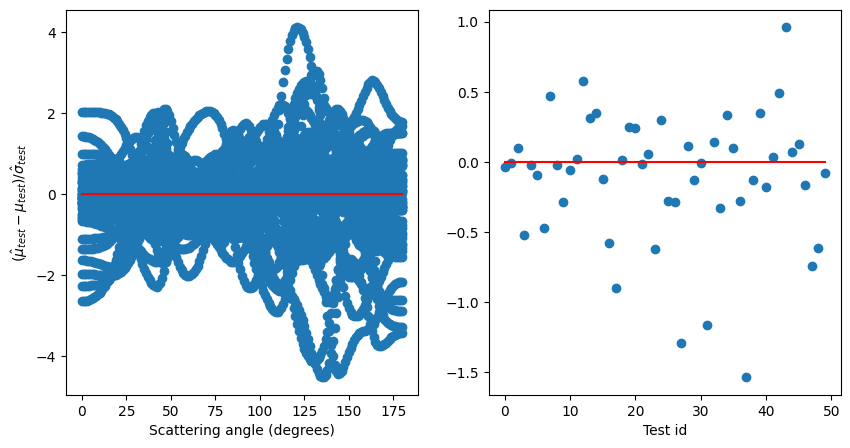

In [14]:
n = pred_m.shape[1]
std_err_f_test = ((pred_m - f_test)/np.sqrt(pred_var)).flatten()
std_err_nf_test = np.mean((pred_m - f_test)/np.sqrt(pred_var), axis=0)
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
xs = np.repeat(x_tr, n)
axs[0].scatter(xs, std_err_f_test)
axs[0].plot(xs, np.repeat(0, len(xs)), color='red')
axs[0].set_xlabel(r'Scattering angle (degrees)')
axs[0].set_ylabel(r'${(\hat{\mu}_{test} - \mu_{test})}/{\hat{\sigma}_{test}}$')
axs[1].scatter(np.arange(0, n), std_err_nf_test)
axs[1].plot(np.arange(0, n), np.repeat(0, n), color='red')
axs[1].set_xlabel(r'Test id')
plt.show()

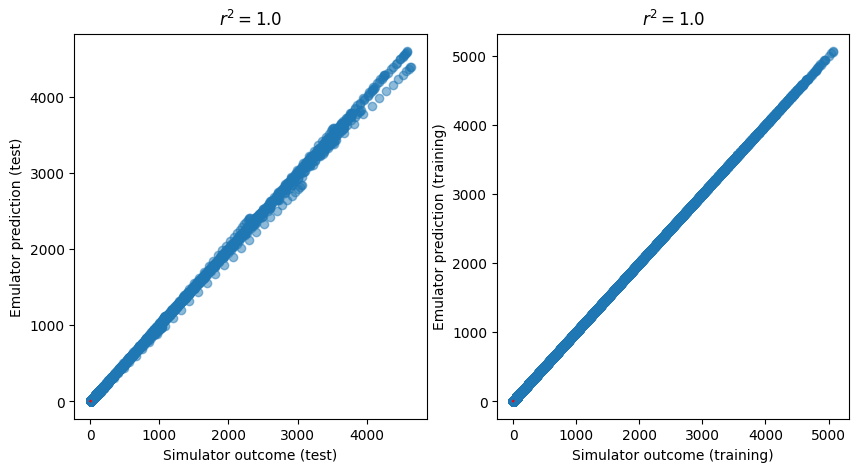

In [15]:
errors_test = (pred_m - f_test).flatten()
errors_tr = (pred_m_tr - f_tr).flatten()
sst_test = np.sum((f_test.flatten() - np.mean(f_test.flatten()))**2)
sst_tr = np.sum((f_tr.flatten() - np.mean(f_tr.flatten()))**2)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].scatter(f_test, pred_m, alpha=0.5)
axs[0].plot(range(1, 5), range(1, 5), color='red')
axs[0].set_xlabel('Simulator outcome (test)')
axs[0].set_ylabel('Emulator prediction (test)')
axs[0].set_title(r'$r^2=$' + str(np.round(1 - np.sum(errors_test**2)/sst_test, 2)))
axs[1].scatter(f_tr, pred_m_tr, alpha=0.5)
axs[1].plot(range(1, 5), range(1, 5), color='red')
axs[1].set_xlabel('Simulator outcome (training)')
axs[1].set_ylabel('Emulator prediction (training)')
axs[1].set_title(r'$r^2=$' + str(np.round(1 - np.sum(errors_tr**2)/sst_tr, 2)))
plt.show()

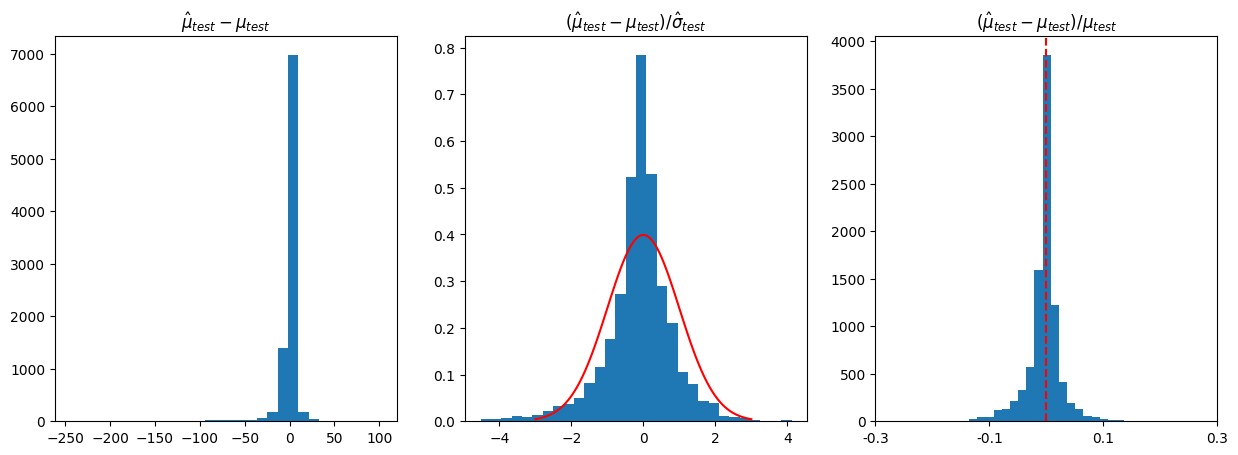

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [16]:
std_err_f = ((pred_m - f_test)/np.sqrt(pred_var)).flatten()
mu = 0
variance = 1
sigma = np.sqrt(variance)
x = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].hist((pred_m - f_test).flatten(), bins=30)
axs[0].set_title(r'$\hat{\mu}_{test} - \mu_{test}$')
axs[1].hist(std_err_f, density=True, bins=30)
axs[1].plot(x, stats.norm.pdf(x, mu, sigma), color='red')
axs[1].set_title(r'${(\hat{\mu}_{test} - \mu_{test})}/{\hat{\sigma}_{test}}$')
axs[2].hist(((pred_m - f_test)/f_test).flatten(), bins=30)
axs[2].set_title(r'${(\hat{\mu}_{test} - \mu_{test})}/{\mu_{test}}$')
l = np.arange(-3, 4, 2)/10
axs[2].set(xticks=l, xticklabels=l)
axs[2].axvline(x=0, ls='--', color='red')
plt.show()

## Build a calibrator via `surmise`

In [17]:
# Observed data
data = np.array([[26, 1243],
                 [31, 887.7],
                 [41, 355.5],
                 [51, 111.5],
                 [61, 26.5],
                 [71, 10.4],
                 [76, 8.3],
                 [81, 7.3],
                 [91, 17.2],
                 [101, 37.6],
                 [111, 48.7],
                 [121, 38.9],
                 [131, 32.4],
                 [141, 36.4],
                 [151, 61.9]])

x = data[:, 0].reshape((15, 1))
y = data[:, 1].reshape((15, 1))

obsvar = (0.45*y) ** 2 # corresponds to approximately 10% std error

In [18]:
# Define a class for prior of 3 parameters
class prior_beta:
    def lpdf(theta):
        return (sps.beta.logpdf((theta[:, 0]-40)/20, 1.5, 1.5) +  # V
                sps.beta.logpdf((theta[:, 1]-0.7)/0.5, 1.5, 1.5) + # r
                sps.beta.logpdf((theta[:, 2]-0.5)/0.3, 1.5, 1.5)).reshape((len(theta), 1)) # a

    def rnd(n):
        th1 = 40 + 20*sps.beta.rvs(1.5, 1.5, size=n) # V
        th2 = 0.7 + 0.5*sps.beta.rvs(1.5, 1.5, size=n) # r
        th3 = 0.5 + 0.3*sps.beta.rvs(1.5, 1.5, size=n) # a
        return np.vstack((th1,
                          th2,
                          th3, )).T

prior_fresco_Ca = prior_beta

In [19]:
# Fit calibrator with different methods and samplers
cal_1 = calibrator(emu=emu_fresco,
                   y=y,
                   x=x,
                   thetaprior=prior_fresco_Ca,
                   method='directbayeswoodbury',
                   yvar= obsvar,
                   args={'sampler': 'PTLMC',
                         'numtemps': 8,
                         'numchain': 4,
                         'maxtemp': 10,
                         'sampperchain':100},
                   )

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1513: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1513: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1513: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an e

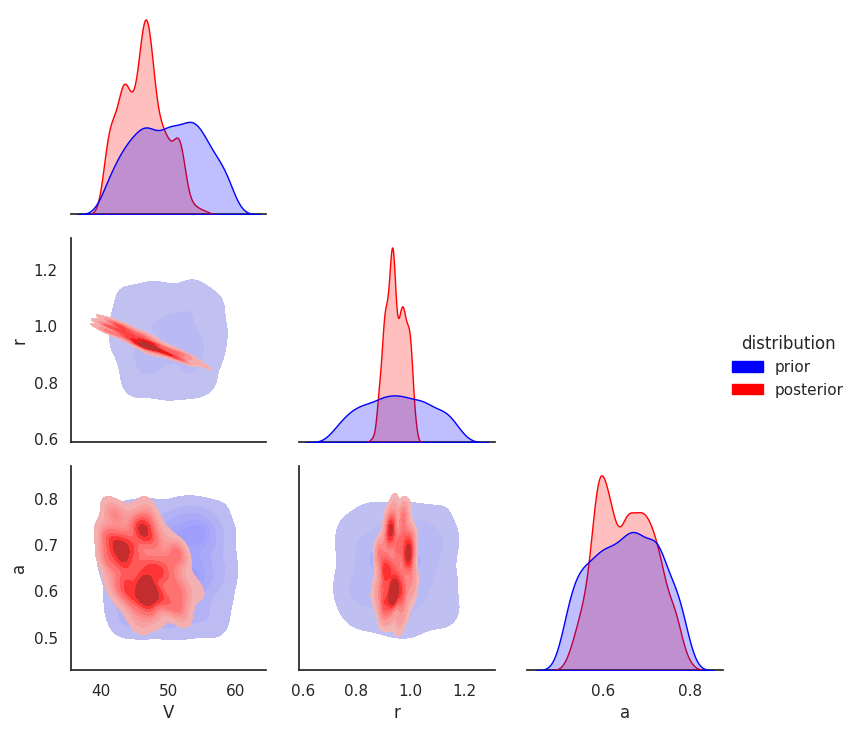

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [20]:
theta_prior = prior_fresco_Ca.rnd(1000)
theta_post = cal_1.theta.rnd(1000)

dfpost = pd.DataFrame(theta_post, columns = ['V', 'r', 'a'])
dfprior = pd.DataFrame(theta_prior, columns = ['V', 'r', 'a'])

df = pd.concat([dfprior, dfpost])
pr = ['prior' for i in range(1000)]
ps = ['posterior' for i in range(1000)]
pr.extend(ps)
df['distribution'] = pr
sns.set(style="white")
g = sns.PairGrid(df, palette=["blue", "red"], corner=True, diag_sharey=False, hue='distribution')
g.map_diag(sns.kdeplot, shade=True)
g.map_lower(sns.kdeplot, fill=True)

g.add_legend()
plt.show()

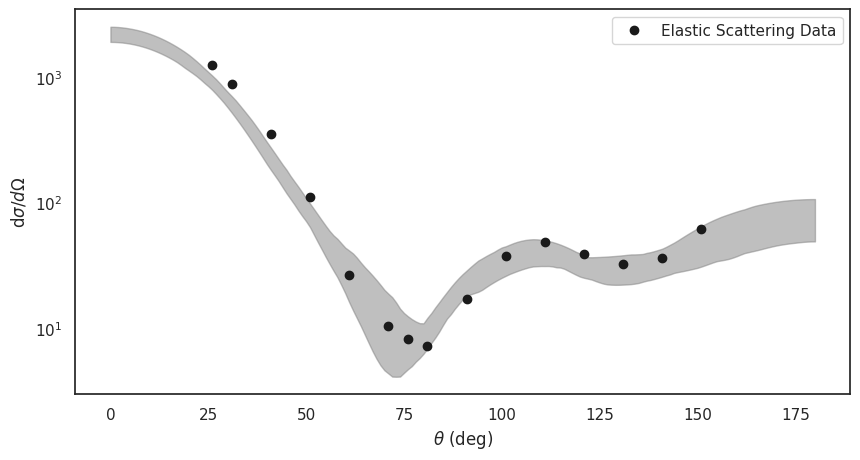

In [21]:

pred_post = emu_fresco.predict(x=x_tr, theta=theta_post)
pred_post_mean = pred_post.mean()
pred_post_var = pred_post.var()

lower = np.quantile(pred_post_mean, 0.025, axis=1)
upper = np.quantile(pred_post_mean, 0.975, axis=1)
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 1, 1)

ax.plot(data[:, 0], data[:, 1], 'ko', label='Elastic Scattering Data')
plt.xlabel(r'$\theta$ (deg)')
plt.ylabel(r'd$\sigma/d\Omega$')
ax.fill_between(range(0, 181), lower, upper, color='grey', alpha=0.5)
plt.legend()
ax.set_yscale('log')
pylab.show()



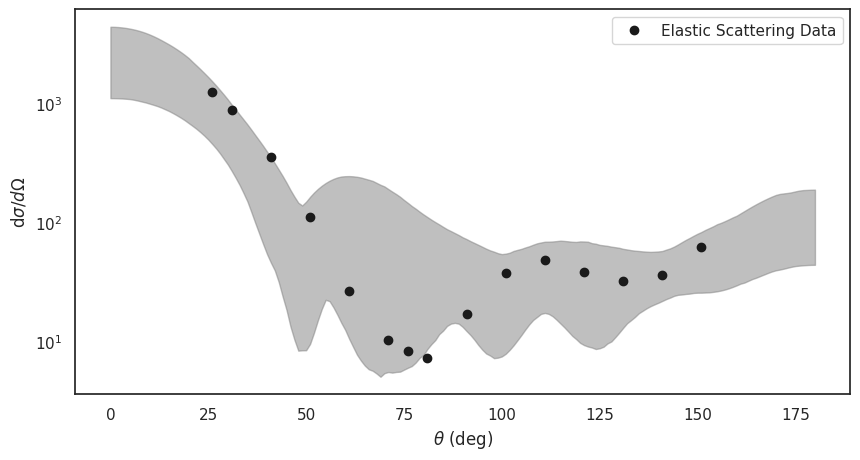

In [22]:
pred_prior = emu_fresco.predict(x=x_tr, theta=theta_prior)
pred_prior_mean = pred_prior.mean()
pred_prior_var = pred_prior.var()

lower = np.quantile(pred_prior_mean, 0.025, axis=1)
upper = np.quantile(pred_prior_mean, 0.975, axis=1)
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 1, 1)

ax.plot(data[:, 0], data[:, 1], 'ko', label='Elastic Scattering Data')
plt.xlabel(r'$\theta$ (deg)')
plt.ylabel(r'd$\sigma/d\Omega$')
ax.fill_between(range(0, 181), lower, upper, color='grey', alpha=0.5)
plt.legend()
ax.set_yscale('log')
pylab.show()